fruits_2d shape: (300, 10000)


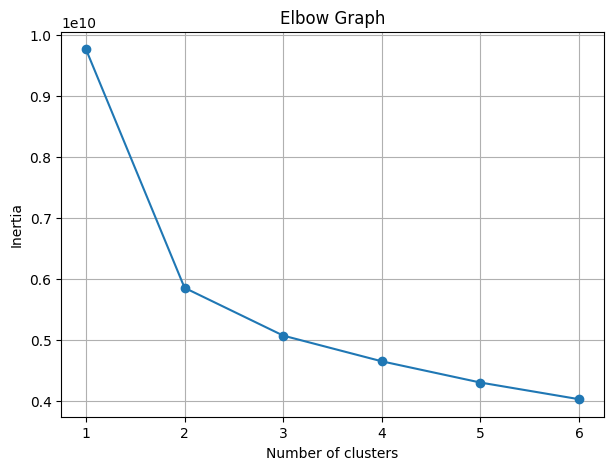


[클러스터 0] 이미지 개수: 91


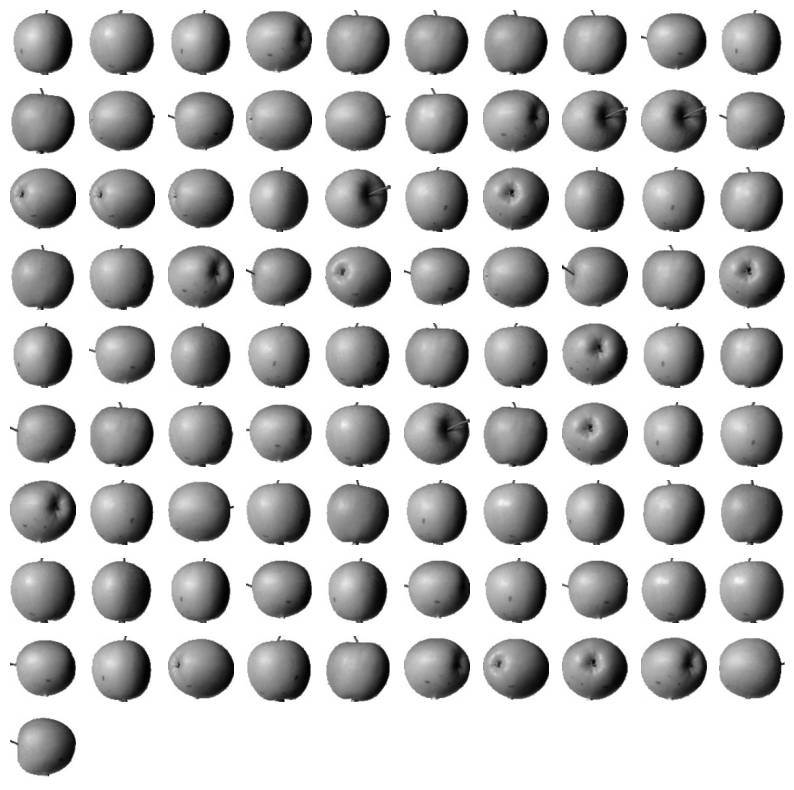


[클러스터 1] 이미지 개수: 98


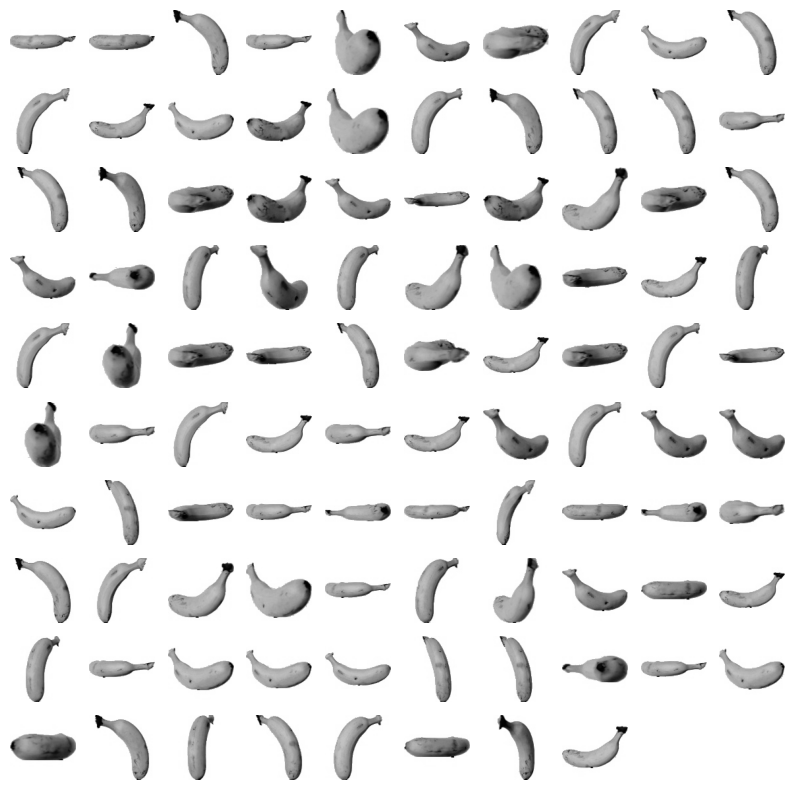


[클러스터 2] 이미지 개수: 111


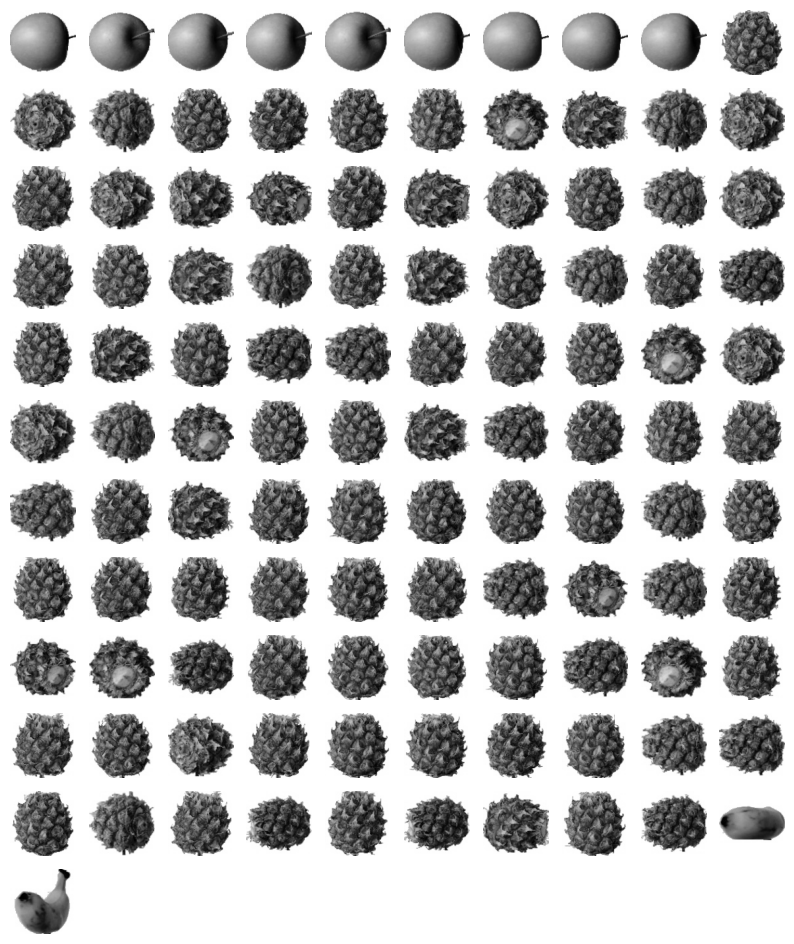


[K-Means centroid 이미지]


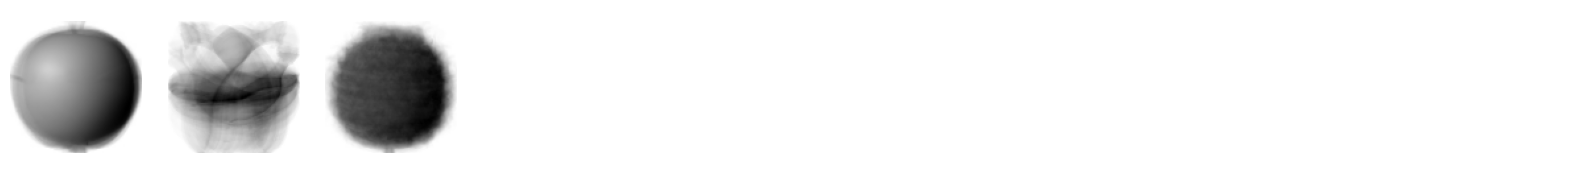


[각 클러스터 평균 이미지]


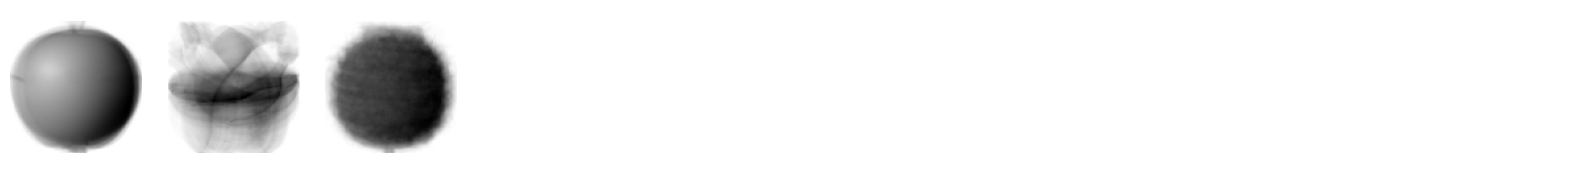

주석: centroid 이미지는 K-Means가 계산한 군집 중심이고 평균 이미지는 실제 클러스터 이미지들의 평균이므로 둘은 비슷한 형태로 나타난다.


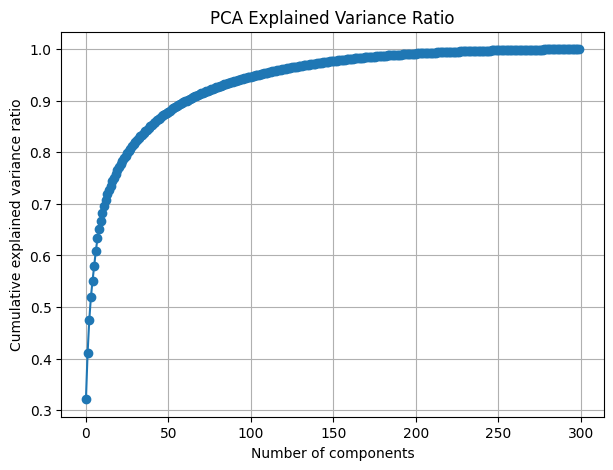

,데이터,학습시간,정확도
0,원본 데이터,0.095705,1.0
1,PCA 50개 주성분,0.006821,1.0


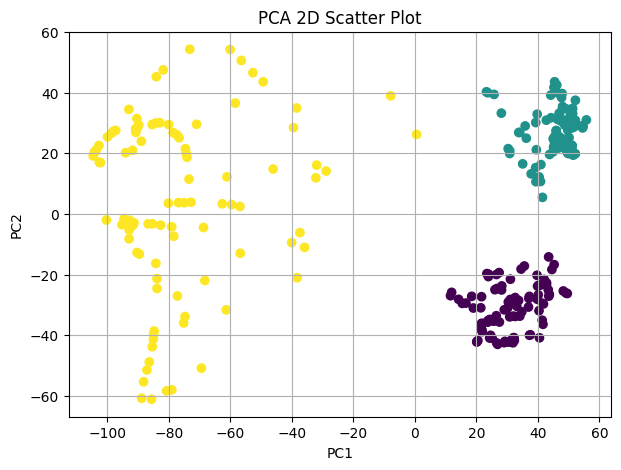


[Iris confusion_matrix]
[[ 0 50  0]
 [48  0  2]
 [14  0 36]]

[Iris ARS 점수]
0.7302382722834697
주석: setosa는 꽃잎 길이와 꽃잎 너비가 다른 품종과 뚜렷하게 달라 K-Means에서도 완벽하게 분리되기 쉽다.

주석: Wine 데이터는 특성마다 단위와 범위가 다르므로 거리 기반 K-Means를 적용하기 전에 StandardScaler로 스케일을 맞춰야 한다.

[이상치 인덱스]
[ 59  69  73  78  95  96 110 121 158]

[탐지된 이상치 특성 값]
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
59     12.37        0.94  1.36               10.6       88.0           1.98   
69     12.21        1.19  1.75               16.8      151.0           1.85   
73     12.99        1.67  2.60               30.0      139.0           3.30   
78     12.33        0.99  1.95               14.8      136.0           1.90   
95     12.47        1.52  2.20               19.0      162.0           2.50   
96     11.81        2.12  2.74               21.5      134.0           1.60   
110    11.46        3.74  1.82               19.5      107.0           3.18   
121    11.56        2.05  3.23               28.5      1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


# =========================================================
# 1. 과일 K-Means — 클러스터 탐색 + PCA 노트북 
# =========================================================

fruits = np.load("./data/fruits_300.npy")

# fruits.reshape(-1, 100*100) shape 확인
fruits_2d = fruits.reshape(-1, 100 * 100)
print("fruits_2d shape:", fruits_2d.shape)


def draw_fruits(arr, ratio=1):
    n = len(arr)
    rows = int(np.ceil(n / 10))
    fig, axs = plt.subplots(rows, 10, figsize=(10 * ratio, rows * ratio))
    axs = axs.ravel()

    for i in range(len(axs)):
        if i < n:
            axs[i].imshow(arr[i], cmap="gray_r")
        axs[i].axis("off")

    plt.show()


inertia = []

for k in range(1, 7):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(fruits_2d)
    inertia.append(km_temp.inertia_)

# 엘보우 그래프 포함
plt.figure(figsize=(7, 5))
plt.plot(range(1, 7), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Graph")
plt.grid()
plt.show()


km = KMeans(n_clusters=3, random_state=42, n_init=10)

# KMeans fit에 y 넣지 않음
km.fit(fruits_2d)


# 클러스터별 draw_fruits 출력 3개
for cluster_num in range(3):
    print(f"\n[클러스터 {cluster_num}] 이미지 개수:", np.sum(km.labels_ == cluster_num))
    draw_fruits(fruits[km.labels_ == cluster_num])


centers = km.cluster_centers_.reshape(-1, 100, 100)

print("\n[K-Means centroid 이미지]")
draw_fruits(centers, ratio=2)


mean_images = []

for cluster_num in range(3):
    mean_img = fruits[km.labels_ == cluster_num].mean(axis=0)
    mean_images.append(mean_img)

mean_images = np.array(mean_images)

print("\n[각 클러스터 평균 이미지]")
draw_fruits(mean_images, ratio=2)


# centroid 이미지와 평균 이미지 비교 주석 1줄
print("주석: centroid 이미지는 K-Means가 계산한 군집 중심이고 평균 이미지는 실제 클러스터 이미지들의 평균이므로 둘은 비슷한 형태로 나타난다.")


scaler = StandardScaler()
fruits_scaled = scaler.fit_transform(fruits_2d)

target = np.array([0] * 100 + [1] * 100 + [2] * 100)

pca = PCA()
pca.fit(fruits_scaled)

# explained_variance_ratio_ 그래프
plt.figure(figsize=(7, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA Explained Variance Ratio")
plt.grid()
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    fruits_scaled,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

lr = LogisticRegression(max_iter=1000)

start = time.time()
lr.fit(X_train, y_train)
original_time = time.time() - start
original_score = lr.score(X_test, y_test)


pca_50 = PCA(n_components=50)
fruits_pca_50 = pca_50.fit_transform(fruits_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    fruits_pca_50,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

lr_pca = LogisticRegression(max_iter=1000)

start = time.time()
lr_pca.fit(X_train_pca, y_train_pca)
pca_time = time.time() - start
pca_score = lr_pca.score(X_test_pca, y_test_pca)


# LR 학습시간 비교 표
result = pd.DataFrame({
    "데이터": ["원본 데이터", "PCA 50개 주성분"],
    "학습시간": [original_time, pca_time],
    "정확도": [original_score, pca_score]
})

display(result)


pca_2d = PCA(n_components=2)
fruits_pca_2d = pca_2d.fit_transform(fruits_scaled)

# 2D 산점도 포함
plt.figure(figsize=(7, 5))
plt.scatter(fruits_pca_2d[:, 0], fruits_pca_2d[:, 1], c=target)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Scatter Plot")
plt.grid()
plt.show()



# =========================================================
# 2. Iris K-Means — 레이블 없이 얼마나 맞출 수 있을까?
# =========================================================

iris = load_iris()

# X = iris.data (4특성), y = iris.target (정답)
X = iris.data
y = iris.target

km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X)

# confusion_matrix(y, km.labels_) 출력
cm = confusion_matrix(y, km.labels_)
print("\n[Iris confusion_matrix]")
print(cm)

# adjusted_rand_score(y, km.labels_) 계산
ars = adjusted_rand_score(y, km.labels_)
print("\n[Iris ARS 점수]")
print(ars)

# "setosa가 완벽 분리된 이유" 주석 한 문장
print("주석: setosa는 꽃잎 길이와 꽃잎 너비가 다른 품종과 뚜렷하게 달라 K-Means에서도 완벽하게 분리되기 쉽다.")



# =========================================================
# 3. 이상 탐지 — Wine 데이터에서 이상치 찾기
# =========================================================

wine = load_wine()
X_wine = wine.data

# StandardScaler로 스케일링 후 KMeans 학습 (이유 주석 기재)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)
print("\n주석: Wine 데이터는 특성마다 단위와 범위가 다르므로 거리 기반 K-Means를 적용하기 전에 StandardScaler로 스케일을 맞춰야 한다.")

km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_scaled)

# km.transform(X_scaled).min(axis=1) 계산
distances = km.transform(X_scaled).min(axis=1)

# np.percentile로 임계값 설정
threshold = np.percentile(distances, 95)

anomaly_idx = np.where(distances >= threshold)[0]

print("\n[이상치 인덱스]")
print(anomaly_idx)

df = pd.DataFrame(X_wine, columns=wine.feature_names)

# 탐지된 이상치 특성 값을 df.iloc[anomaly_idx]로 출력
print("\n[탐지된 이상치 특성 값]")
print(df.iloc[anomaly_idx])